# CS180 (CS280A) Project 2: Fun with Filters and Frequencies!

- Part 1.1: Convolutions from Scratch
- Part 1.2: Finite Difference Operator
- Part 1.3: Derivative of Gaussian (DoG) Filter
- Part 1 Bells & Whistles: Gradient Orientation (HSV)
- Part 2.1: Image "Sharpening"
- Part 2.2: Hybrid Images (+ Bells & Whistles: color)
- Part 2.3: Gaussian and Laplacian Stacks
- Part 2.4: Multiresolution Blending (+ Bells & Whistles: color)

## Setup

In [2]:
import os
import time

import numpy as np
import scipy.signal
import cv2
import skimage as sk
import skimage.io as skio
import matplotlib.pyplot as plt

# Config
DATA_DIR = 'data'
OUT_DIR = 'out'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# I/O helpers
def load_image(path, gray=False):
    """Read an image as float in [0, 1]; optionally convert to grayscale."""
    im = skio.imread(path)
    if im.ndim == 3 and im.shape[2] == 4:
        im = im[..., :3]
    im = sk.img_as_float(im)
    if gray and im.ndim == 3:
        im = sk.color.rgb2gray(im)
    return im


def save_image(im, name):
    """Clip to [0, 1] and save as uint8 under OUT_DIR."""
    im = np.clip(im, 0, 1)
    skio.imsave(os.path.join(OUT_DIR, name), sk.img_as_ubyte(im))


def show_images(ims, titles=None, cmap='gray', figsize_per=4):
    """Show a row of images side by side."""
    n = len(ims)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per * n, figsize_per))
    axes = np.atleast_1d(axes)
    for i, (ax, im) in enumerate(zip(axes, ims)):
        ax.imshow(im, cmap=cmap if im.ndim == 2 else None)
        ax.set_title(titles[i] if titles else '')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Part 1: Fun with Filters

## Part 1.1: Convolutions from Scratch

Convolution flips the kernel and slides it over the zero-padded image:
$(I * K)[i, j] = \sum_{m,n} I_{pad}[i+m, j+n] \, K_{flip}[m, n]$.

Padding modes (matching `scipy.signal.convolve2d`):
- **full**: pad `kh-1` rows / `kw-1` cols on every side, so the output is `(H+kh-1, W+kw-1)`.
- **same**: pad `kh//2` on top/left and `(kh-1)//2` on bottom/right, so the output is `(H, W)`, centered like scipy's.

In [4]:
# Convolution helpers
def pad_zeros(im, kh, kw, mode='same'):
    """Zero-pad a 2D image for a (kh, kw) kernel in 'same' or 'full' mode."""
    if mode == 'full':
        top, bottom, left, right = kh - 1, kh - 1, kw - 1, kw - 1
    elif mode == 'same':
        top, bottom, left, right = kh // 2, (kh - 1) // 2, kw // 2, (kw - 1) // 2
    else:
        raise ValueError(f"unknown mode: {mode}")
    H, W = im.shape
    padded = np.zeros((H + top + bottom, W + left + right), dtype=np.float64)
    padded[top:top + H, left:left + W] = im
    return padded


def conv2d_four_loops(im, kernel, mode='same'):
    """2D convolution with four explicit for loops."""
    kh, kw = kernel.shape
    k = kernel[::-1, ::-1]  # flip the filter
    padded = pad_zeros(im, kh, kw, mode)
    out_h, out_w = padded.shape[0] - kh + 1, padded.shape[1] - kw + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            acc = 0.0
            for m in range(kh):
                for n in range(kw):
                    acc += padded[i + m, j + n] * k[m, n]
            out[i, j] = acc
    return out


def conv2d_two_loops(im, kernel, mode='same'):
    """2D convolution with two for loops (inner sum vectorized over the patch)."""
    kh, kw = kernel.shape
    k = kernel[::-1, ::-1]  # flip the filter
    padded = pad_zeros(im, kh, kw, mode)
    out_h, out_w = padded.shape[0] - kh + 1, padded.shape[1] - kw + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(padded[i:i + kh, j:j + kw] * k)
    return out

### Correctness check against `scipy.signal.convolve2d`
Random image, several kernel shapes (odd, even, non-square, non-symmetric), both padding modes.

In [5]:
rng = np.random.default_rng(0)
test_im = rng.random((20, 25))
for kshape in [(3, 3), (1, 3), (3, 1), (4, 4), (5, 2), (9, 9)]:
    k = rng.random(kshape)
    for mode in ['same', 'full']:
        ref = scipy.signal.convolve2d(test_im, k, mode=mode, boundary='fill', fillvalue=0)
        ok4 = np.allclose(conv2d_four_loops(test_im, k, mode), ref)
        ok2 = np.allclose(conv2d_two_loops(test_im, k, mode), ref)
        print(f"kernel {kshape}, {mode:>4}: four_loops={ok4}, two_loops={ok2}, shape={ref.shape}")

kernel (3, 3), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (3, 3), full: four_loops=True, two_loops=True, shape=(22, 27)
kernel (1, 3), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (1, 3), full: four_loops=True, two_loops=True, shape=(20, 27)
kernel (3, 1), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (3, 1), full: four_loops=True, two_loops=True, shape=(22, 25)
kernel (4, 4), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (4, 4), full: four_loops=True, two_loops=True, shape=(23, 28)
kernel (5, 2), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (5, 2), full: four_loops=True, two_loops=True, shape=(24, 26)
kernel (9, 9), same: four_loops=True, two_loops=True, shape=(20, 25)
kernel (9, 9), full: four_loops=True, two_loops=True, shape=(28, 33)


### Filters and input image
The 9x9 box filter averages a neighborhood; $D_x = [1, 0, -1]$ and $D_y = [1, 0, -1]^T$ are finite differences.

Put a picture of yourself at `data/selfie.jpg` (falls back to a skimage sample if missing). It is downsized so the loop versions run in reasonable time.

In [ ]:
from skimage.transform import resize

box = np.ones((9, 9)) / 81.0
Dx = np.array([[1, 0, -1]], dtype=np.float64)
Dy = Dx.T

SELFIE_PATH = os.path.join(DATA_DIR, 'selfie.jpg')
MAX_SIDE = 300
selfie = load_image(SELFIE_PATH, gray=True)
scale = MAX_SIDE / max(selfie.shape)
if scale < 1:
    selfie = resize(selfie, (round(selfie.shape[0] * scale), round(selfie.shape[1] * scale)), anti_aliasing=True)
print("selfie shape:", selfie.shape)

selfie shape: (300, 225)


### Runtime comparison

In [7]:
timings = {}
results = {}
for name, fn in [('four_loops', conv2d_four_loops),
                 ('two_loops', conv2d_two_loops),
                 ('scipy', lambda im, k, mode: scipy.signal.convolve2d(im, k, mode=mode))]:
    t0 = time.perf_counter()
    results[name] = fn(selfie, box, 'same')
    timings[name] = time.perf_counter() - t0
    print(f"{name:>10}: {timings[name]:8.4f} s")

print("max |four_loops - scipy| =", np.abs(results['four_loops'] - results['scipy']).max())
print("max |two_loops  - scipy| =", np.abs(results['two_loops'] - results['scipy']).max())

four_loops:   0.6833 s
 two_loops:   0.0940 s
     scipy:   0.0061 s
max |four_loops - scipy| = 9.992007221626409e-16
max |two_loops  - scipy| = 5.551115123125783e-16


### Box filter, $D_x$, $D_y$ on the selfie

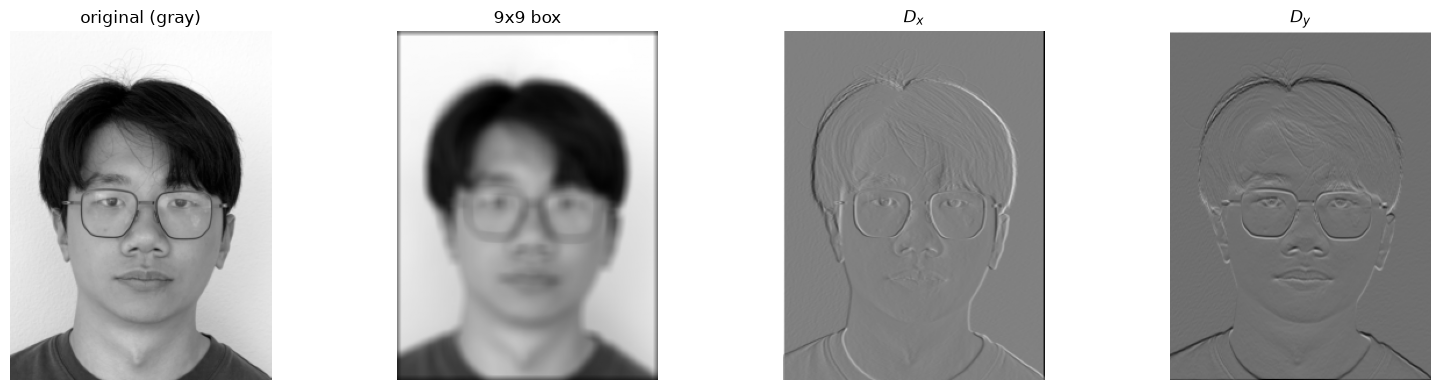

In [8]:
selfie_box = conv2d_two_loops(selfie, box, 'same')
selfie_dx = conv2d_two_loops(selfie, Dx, 'same')
selfie_dy = conv2d_two_loops(selfie, Dy, 'same')

show_images([selfie, selfie_box, selfie_dx, selfie_dy],
            ['original (gray)', '9x9 box', '$D_x$', '$D_y$'])

save_image(selfie, 'p11_selfie_gray.png')
save_image(selfie_box, 'p11_selfie_box.png')
# derivatives are in [-1, 1]; map to [0, 1] for saving (0 -> mid gray)
save_image(selfie_dx / 2 + 0.5, 'p11_selfie_dx.png')
save_image(selfie_dy / 2 + 0.5, 'p11_selfie_dy.png')

### Observations
- **Correctness:** both loop implementations match `scipy.signal.convolve2d` (zero fill) to floating-point precision in both `same` and `full` modes.
- **Runtime:** see the timings above. Four loops is the slowest because every multiply-add runs in the Python interpreter. Two loops moves the inner kernel sum into numpy. scipy is compiled C, so it is orders of magnitude faster.
- **Boundaries:** with zero padding, the box-filtered image darkens along the borders because the window averages in zeros. The $D_x$/$D_y$ outputs show a spurious strong edge at the image border for the same reason. scipy's `boundary='symm'` or `'wrap'` would avoid this; our implementation (and scipy's default `'fill'`) uses zeros.

## Part 1.2: Finite Difference Operator

Convolving with $D_x = [1, 0, -1]$ and $D_y = [1, 0, -1]^T$ gives the partial derivatives $\partial I/\partial x$ and $\partial I/\partial y$.
The gradient magnitude $\|\nabla I\| = \sqrt{(\partial I/\partial x)^2 + (\partial I/\partial y)^2}$ is large wherever the intensity changes quickly (edges) in *any* direction.
Thresholding the magnitude turns it into a binary edge image.

From here on `scipy.signal.convolve2d` is used for speed. `boundary='symm'` mirrors the image at the border, so the zero-padding border artifacts seen in Part 1.1 do not show up as fake edges.

In [9]:
def image_gradients(im, dx_filter, dy_filter):
    """Convolve with the x and y derivative filters; returns (dx, dy), same size as im."""
    dx = scipy.signal.convolve2d(im, dx_filter, mode='same', boundary='symm')
    dy = scipy.signal.convolve2d(im, dy_filter, mode='same', boundary='symm')
    return dx, dy


def gradient_magnitude(dx, dy):
    """Per-pixel L2 norm of the gradient."""
    return np.sqrt(dx ** 2 + dy ** 2)


def binarize(mag, threshold):
    """1 where the gradient magnitude exceeds the threshold, else 0."""
    return (mag > threshold).astype(np.float64)

In [10]:
CAMERAMAN_PATH = os.path.join(DATA_DIR, 'cameraman.png')
cameraman = load_image(CAMERAMAN_PATH, gray=True)
print("cameraman shape:", cameraman.shape, "range:", cameraman.min(), cameraman.max())

cameraman shape: (542, 540) range: 0.027450980392156862 1.0


gradient magnitude range: 0.0 0.9994769874119228


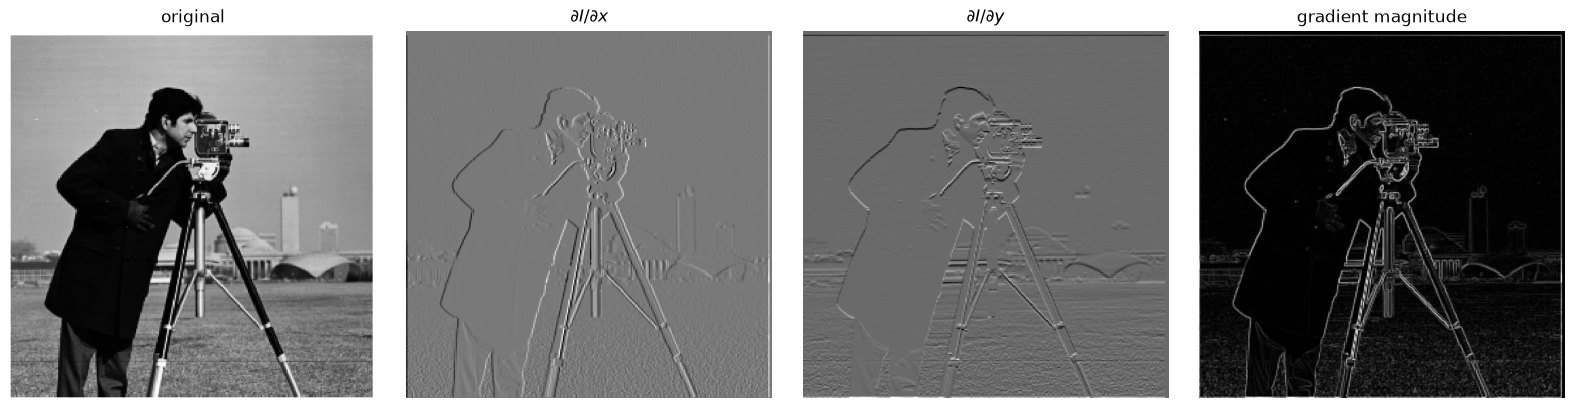

In [11]:
cam_dx, cam_dy = image_gradients(cameraman, Dx, Dy)
cam_mag = gradient_magnitude(cam_dx, cam_dy)
print("gradient magnitude range:", cam_mag.min(), cam_mag.max())

show_images([cameraman, cam_dx, cam_dy, cam_mag],
            ['original', r'$\partial I/\partial x$', r'$\partial I/\partial y$', 'gradient magnitude'])

save_image(cam_dx / 2 + 0.5, 'p12_cam_dx.png')          # [-1, 1] -> [0, 1], 0 = mid gray
save_image(cam_dy / 2 + 0.5, 'p12_cam_dy.png')
save_image(cam_mag / cam_mag.max(), 'p12_cam_mag.png')   # normalize for saving

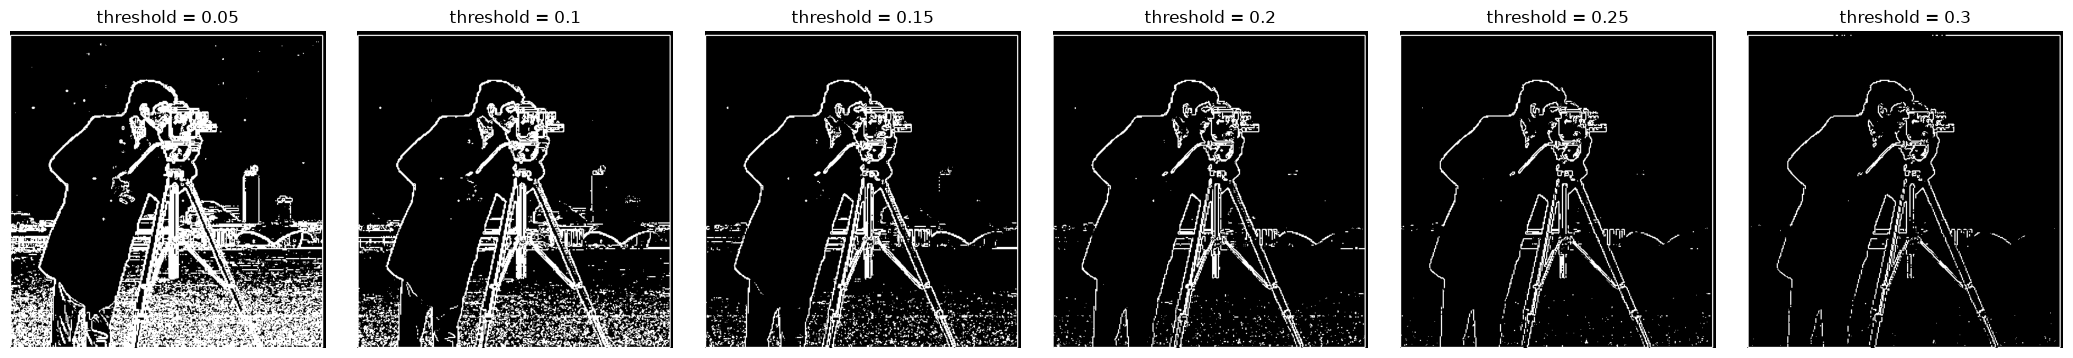

In [14]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
show_images([binarize(cam_mag, t) for t in thresholds],
            [f'threshold = {t}' for t in thresholds], figsize_per=3.5)


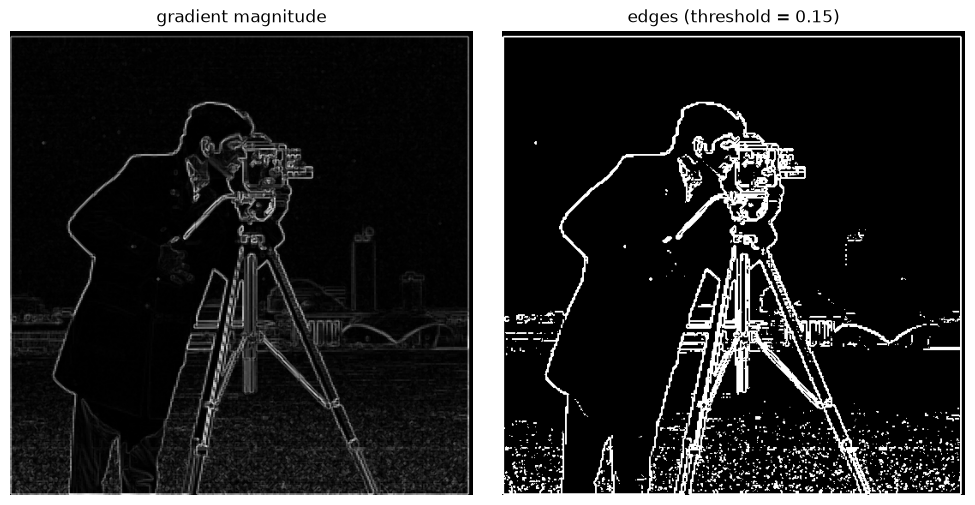

In [15]:
EDGE_THRESHOLD = 0.15  # chosen from the sweep above
cam_edges = binarize(cam_mag, EDGE_THRESHOLD)

show_images([cam_mag, cam_edges],
            ['gradient magnitude', f'edges (threshold = {EDGE_THRESHOLD})'], figsize_per=5)
save_image(cam_edges, 'p12_cam_edges.png')

### Choosing the threshold
- **Low thresholds (0.05–0.10):** every real edge is present, but the grass in the lower half turns into dense white speckle. The finite difference responds to pixel-level texture and noise just as strongly as to object boundaries.
- **High thresholds (≥ 0.30):** the grass is almost gone, but weaker real edges break apart (the coat, tripod legs, buildings in the background).
- **Chosen: 0.15.** The outline of the cameraman, the camera and the tripod stay mostly continuous, and most of the grass noise is gone. Some speckle remains; removing it all would cost real edges.

This trade-off happens because $D_x$/$D_y$ look only at neighboring pixels, so they amplify high-frequency noise. Part 1.3 fixes this by smoothing with a Gaussian first.

## Part 1.3: Derivative of Gaussian (DoG) Filter

The finite difference results in 1.2 were noisy: $D_x$/$D_y$ amplify high-frequency texture such as the grass.
Here we first smooth with a Gaussian $G$ (a low-pass filter) and then take derivatives.

The 2D Gaussian is built from `cv2.getGaussianKernel` (a 1D column vector $g$) as the outer product $G = g\,g^T$.
The kernel size is $2\lceil 3\sigma \rceil + 1$, so it covers ±3σ, where almost all of the Gaussian's weight lies.

Because convolution is associative, $(I * G) * D_x = I * (G * D_x)$. So we can also build **Derivative of Gaussian (DoG)** filters $G * D_x$ and $G * D_y$ once, then use a single convolution per direction.


In [16]:
# Gaussian / DoG helpers
def gaussian_kernel_2d(sigma, ksize=None):
    """2D Gaussian as the outer product of cv2's 1D Gaussian with itself."""
    if ksize is None:
        ksize = int(2 * np.ceil(3 * sigma) + 1)
    g = cv2.getGaussianKernel(ksize, sigma)  # (ksize, 1) column vector, sums to 1
    return g @ g.T


def dog_filters(G, dx_filter, dy_filter):
    """Derivative of Gaussian filters: G convolved with each finite difference (full mode keeps every value)."""
    dog_x = scipy.signal.convolve2d(G, dx_filter, mode='full')
    dog_y = scipy.signal.convolve2d(G, dy_filter, mode='full')
    return dog_x, dog_y


Gaussian kernel shape: (13, 13)  sum: 1.0000000000000002


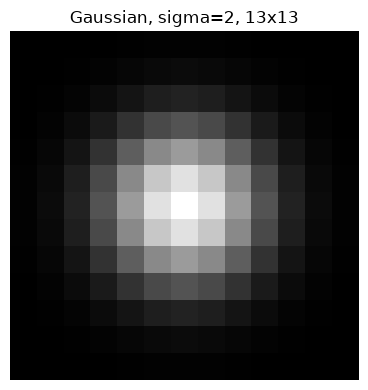

In [17]:
SIGMA=2
G = gaussian_kernel_2d(SIGMA)
print("Gaussian kernel shape:", G.shape, " sum:", G.sum())

show_images([G], [f'Gaussian, sigma={SIGMA}, {G.shape[0]}x{G.shape[1]}'], figsize_per=4)

blurred gradient magnitude range: 4.50510606695661e-06 0.3351774875914863


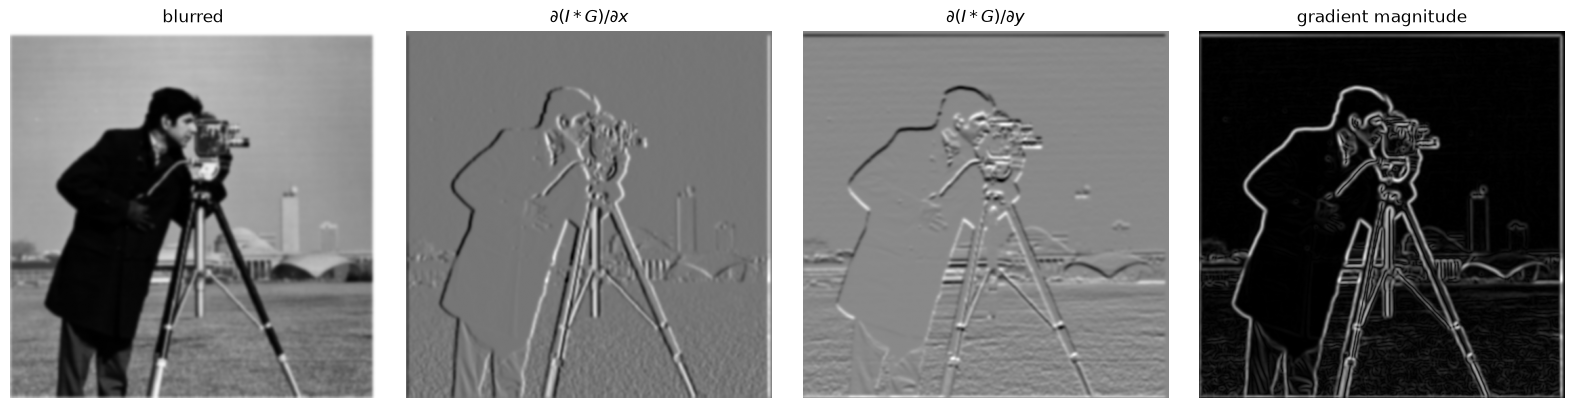

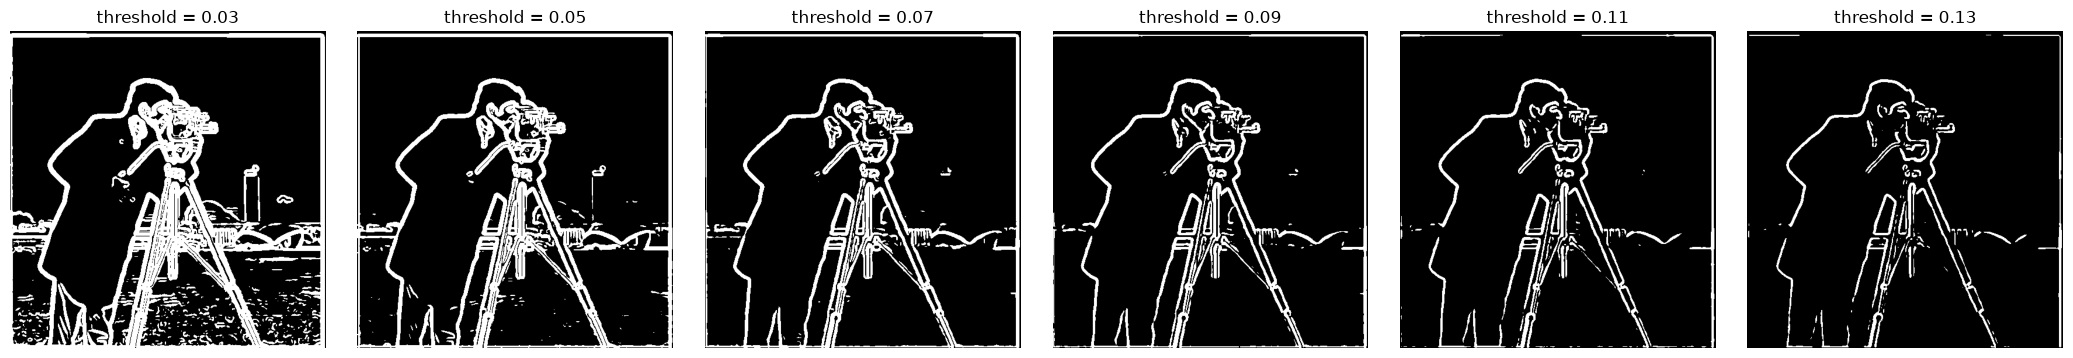

In [18]:
cam_blur = scipy.signal.convolve2d(cameraman, G, mode='same', boundary='symm')
blur_dx, blur_dy = image_gradients(cam_blur, Dx, Dy)
blur_mag = gradient_magnitude(blur_dx, blur_dy)
print("blurred gradient magnitude range:", blur_mag.min(), blur_mag.max())

show_images([cam_blur, blur_dx, blur_dy, blur_mag],
            ['blurred', r'$\partial (I*G)/\partial x$', r'$\partial (I*G)/\partial y$', 'gradient magnitude'])

blur_thresholds = [0.03, 0.05, 0.07, 0.09, 0.11, 0.13]
show_images([binarize(blur_mag, t) for t in blur_thresholds],
            [f'threshold = {t}' for t in blur_thresholds], figsize_per=3.5)

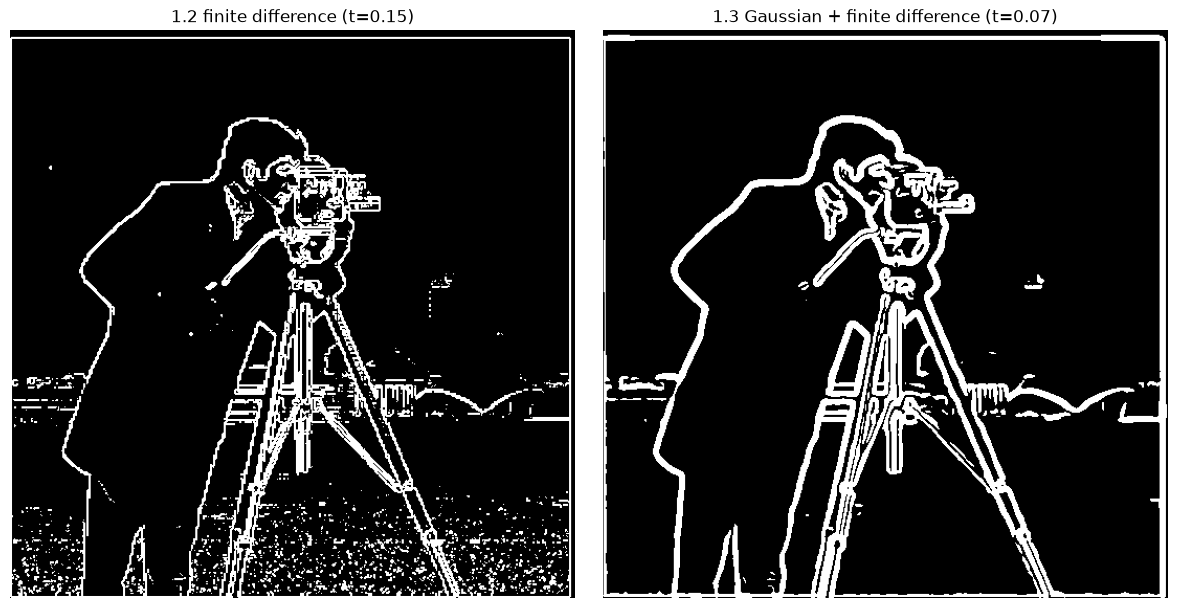

In [19]:
BLUR_EDGE_THRESHOLD = 0.07  # chosen from the sweep above
blur_edges = binarize(blur_mag, BLUR_EDGE_THRESHOLD)

show_images([cam_edges, blur_edges],
            [f'1.2 finite difference (t={EDGE_THRESHOLD})', f'1.3 Gaussian + finite difference (t={BLUR_EDGE_THRESHOLD})'],
            figsize_per=6)

save_image(cam_blur, 'p13_cam_blur.png')
save_image(blur_dx / 2 + 0.5, 'p13_blur_dx.png')
save_image(blur_dy / 2 + 0.5, 'p13_blur_dy.png')
save_image(blur_mag / blur_mag.max(), 'p13_blur_mag.png')
save_image(blur_edges, 'p13_blur_edges.png')

DoG_x shape: (13, 15)  DoG_y shape: (15, 13)


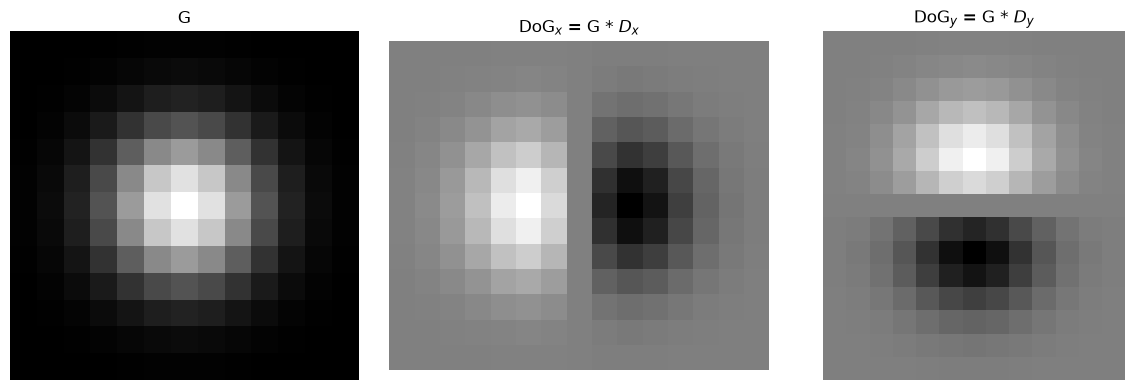

In [20]:
dog_x, dog_y = dog_filters(G, Dx, Dy)
print("DoG_x shape:", dog_x.shape, " DoG_y shape:", dog_y.shape)

show_images([G, dog_x, dog_y], ['G', r'DoG$_x$ = G * $D_x$', r'DoG$_y$ = G * $D_y$'], figsize_per=4)

def _to_display(k, scale=20):
    """Normalize a filter to [0, 1] and enlarge it with nearest-neighbor pixels for saving."""
    k = (k - k.min()) / (k.max() - k.min())
    return np.kron(k, np.ones((scale, scale)))

save_image(_to_display(G), 'p13_gaussian_kernel.png')
save_image(_to_display(dog_x), 'p13_dog_x.png')
save_image(_to_display(dog_y), 'p13_dog_y.png')

max |dx two-step - dx DoG|  = 1.0491824423142226e-15
max |dy two-step - dy DoG|  = 9.684093804640526e-16
max |mag two-step - mag DoG| = 9.796850830579018e-16
edge pixels that differ: 0


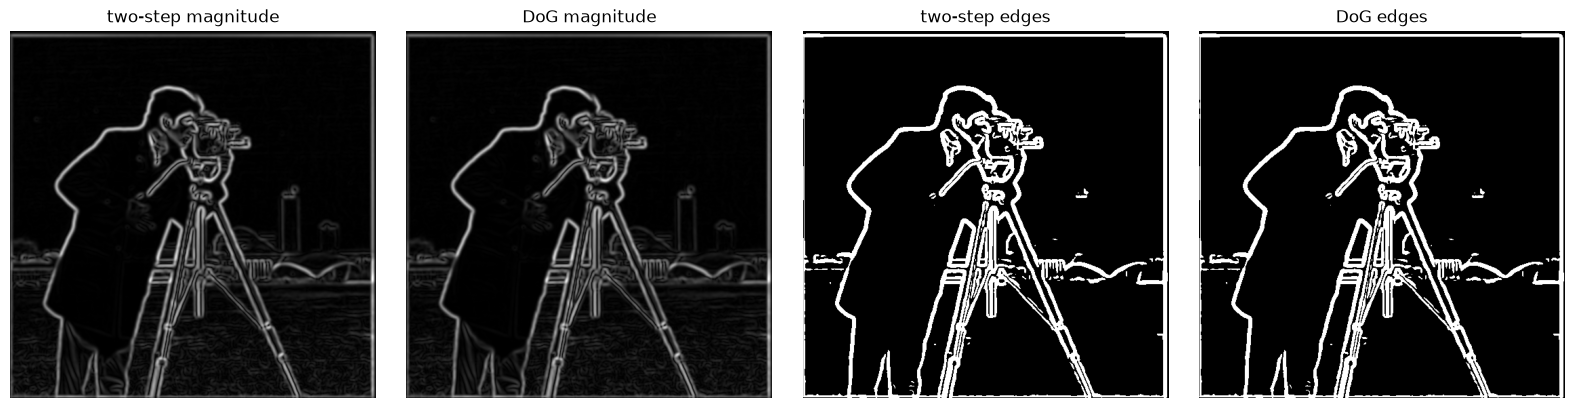

In [21]:
dog_dx = scipy.signal.convolve2d(cameraman, dog_x, mode='same', boundary='symm')
dog_dy = scipy.signal.convolve2d(cameraman, dog_y, mode='same', boundary='symm')
dog_mag = gradient_magnitude(dog_dx, dog_dy)
dog_edges = binarize(dog_mag, BLUR_EDGE_THRESHOLD)

print("max |dx two-step - dx DoG|  =", np.abs(blur_dx - dog_dx).max())
print("max |dy two-step - dy DoG|  =", np.abs(blur_dy - dog_dy).max())
print("max |mag two-step - mag DoG| =", np.abs(blur_mag - dog_mag).max())
print("edge pixels that differ:", int(np.sum(blur_edges != dog_edges)))

show_images([blur_mag, dog_mag, blur_edges, dog_edges],
            ['two-step magnitude', 'DoG magnitude', 'two-step edges', 'DoG edges'])
save_image(dog_edges, 'p13_dog_edges.png')

### What differences do you see?
- **Much less noise.** The Gaussian removes high frequencies before differentiating, so the grass texture no longer produces strong gradients. The edge image is clean at threshold 0.07, while 1.2 still had speckle at 0.15.
- **Thicker, smoother edges.** Blurring spreads each edge over several pixels, so edges are a few pixels wide and continuous instead of thin and broken. Fine details (small background buildings, thin tripod parts) get weaker or merge.
- **Lower threshold.** The Gaussian also lowers the peak gradient values, so the best threshold is much smaller than in 1.2 (0.07 vs 0.25).
- **σ trade-off.** Larger σ gives less noise but loses fine detail; smaller σ gives the reverse. σ = 2 was a good balance for this image.

### DoG vs. two-step
The DoG filters look like a smoothed $[1, 0, -1]$: one positive lobe and one negative lobe along x (or y).
Convolving once with DoG gives the same result as blurring and then differentiating: the maximum difference is about 1.05e-15 (floating-point rounding) and no edge pixels differ. This is associativity of convolution. The DoG version is cheaper when you apply it to many images, because the filter is built only once.

## Part 1 Bells & Whistles: Gradient Orientation

The gradient orientation at each pixel is $\theta = \operatorname{atan2}(\partial I/\partial y,\ \partial I/\partial x) \in (-\pi, \pi]$, the direction in which intensity increases fastest (perpendicular to the edge).

**Computing atan2 without built-in angle functions.**
1. *Reduce to one octant:* using $|x|, |y|$, compute $t = \min/\max \in [0, 1]$, so $\arctan t \in [0, \pi/4]$.
2. *Half-angle reduction:* $\arctan t = 2 \arctan\!\left(\dfrac{t}{1 + \sqrt{1 + t^2}}\right)$. Applying it twice shrinks $t$ to $\le \tan(\pi/16) \approx 0.2$.
3. *Taylor series:* $\arctan t = t - t^3/3 + t^5/5 - \dots$ converges very fast for $t \le 0.2$ (12 terms reach float64 precision). Multiply back by $2^2$.
4. *Undo the reductions:* if $|y| > |x|$ the angle is $\pi/2 - a$; if $x < 0$ it is $\pi - a$; if $y < 0$ negate it.

**Visualizing in HSV:** hue = orientation (hue is cyclic, just like angle, so $-\pi$ and $\pi$ get the same color), saturation = 1, value = gradient magnitude (so flat regions, where orientation is meaningless, are dark).

We use the DoG gradients from 1.3, because the raw finite differences give noisy orientations.


In [22]:
# Arctangent from scratch (no np.arctan / np.arctan2 / np.angle)
def atan_unit(t, n_halvings=2, n_terms=12):
    """arctan(t) for t in [0, 1]: half-angle reduction, then Taylor series."""
    t = np.asarray(t, dtype=np.float64)
    for _ in range(n_halvings):
        t = t / (1 + np.sqrt(1 + t ** 2))  # arctan(t) = 2 * arctan(this)
    t2 = t * t
    result = np.zeros_like(t)
    power = t.copy()
    for n in range(n_terms):
        result += ((-1) ** n) * power / (2 * n + 1)
        power = power * t2
    return result * (2 ** n_halvings)


def atan2_custom(y, x):
    """Four-quadrant arctangent in (-pi, pi], built on atan_unit."""
    y = np.asarray(y, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    ax, ay = np.abs(x), np.abs(y)
    swap = ay > ax                      # steeper than 45 degrees: use x/y instead of y/x
    num = np.where(swap, ax, ay)
    den = np.where(swap, ay, ax)
    t = np.where(den > 0, num / np.where(den > 0, den, 1.0), 0.0)  # in [0, 1]; (0, 0) -> 0
    a = atan_unit(t)                    # [0, pi/4]
    a = np.where(swap, np.pi / 2 - a, a)  # first quadrant [0, pi/2]
    a = np.where(x < 0, np.pi - a, a)     # left half-plane
    a = np.where(y < 0, -a, a)            # lower half-plane
    return a

In [23]:
# Arctangent from scratch
def atan_unit(t, n_halvings=2, n_terms=12):
    """arctan(t) for t in [0, 1]: half-angle reduction, then Taylor series."""
    t = np.asarray(t, dtype=np.float64)
    for _ in range(n_halvings):
        t = t / (1 + np.sqrt(1 + t ** 2))  # arctan(t) = 2 * arctan(this)
    t2 = t * t
    result = np.zeros_like(t)
    power = t.copy()
    for n in range(n_terms):
        result += ((-1) ** n) * power / (2 * n + 1)
        power = power * t2
    return result * (2 ** n_halvings)


def atan2_custom(y, x):
    """Four-quadrant arctangent in (-pi, pi], built on atan_unit."""
    y = np.asarray(y, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    ax, ay = np.abs(x), np.abs(y)
    swap = ay > ax                      # steeper than 45 degrees: use x/y instead of y/x
    num = np.where(swap, ax, ay)
    den = np.where(swap, ay, ax)
    t = np.where(den > 0, num / np.where(den > 0, den, 1.0), 0.0)  # in [0, 1]; (0, 0) -> 0
    a = atan_unit(t)                    # [0, pi/4]
    a = np.where(swap, np.pi / 2 - a, a)  # first quadrant [0, pi/2]
    a = np.where(x < 0, np.pi - a, a)     # left half-plane
    a = np.where(y < 0, -a, a)            # lower half-plane
    return a

In [24]:
rng = np.random.default_rng(0)
ys, xs = rng.normal(size=100000), rng.normal(size=100000)
ys[:4], xs[:4] = [0, 0, 1, -1], [1, -1, 0, 0]   # axis cases
print("max |atan2_custom - np.arctan2| =", np.abs(atan2_custom(ys, xs) - np.arctan2(ys, xs)).max())

max |atan2_custom - np.arctan2| = 8.881784197001252e-16


In [26]:
from matplotlib.colors import hsv_to_rgb

def orientation_to_rgb(theta, value):
    """Hue = orientation mapped from (-pi, pi] to (0, 1], saturation = 1, value given in [0, 1]."""
    hsv = np.stack([(theta + np.pi) / (2 * np.pi),
                    np.ones_like(theta),
                    np.clip(value, 0, 1)], axis=-1)
    return hsv_to_rgb(hsv)


def color_wheel(size=201):
    """Legend: each direction from the center colored the way orientation_to_rgb colors that angle."""
    c = size // 2
    yy, xx = np.mgrid[0:size, 0:size] - c   # rows go down, same as image y
    inside = (np.sqrt(xx ** 2 + yy ** 2) <= c).astype(np.float64)
    return orientation_to_rgb(atan2_custom(yy, xx), inside)

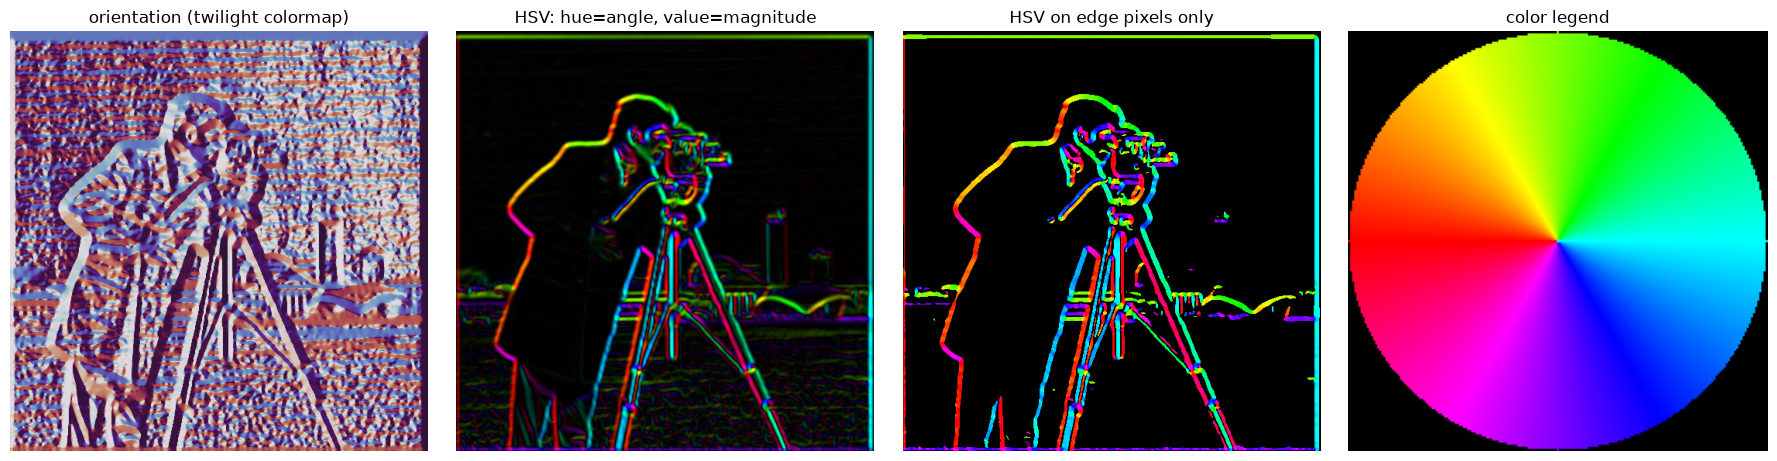

In [27]:
cam_theta = atan2_custom(dog_dy, dog_dx)

# value = magnitude, normalized (99th percentile, so a few very strong edges don't make everything else dark)
mag_norm = dog_mag / np.percentile(dog_mag, 99)
orient_rgb = orientation_to_rgb(cam_theta, mag_norm)
# only on edge pixels from 1.3
orient_edges_rgb = orientation_to_rgb(cam_theta, (dog_mag > BLUR_EDGE_THRESHOLD).astype(np.float64))
wheel = color_wheel()

show_images([cam_theta, orient_rgb, orient_edges_rgb, wheel],
            ['orientation (twilight colormap)', 'HSV: hue=angle, value=magnitude',
             'HSV on edge pixels only', 'color legend'],
            cmap='twilight', figsize_per=4.5)

save_image(orient_rgb, 'p1bw_orientation_hsv.png')
save_image(orient_edges_rgb, 'p1bw_orientation_edges.png')
save_image(wheel, 'p1bw_color_wheel.png')

### Observations
- **Raw orientation (first panel)** is noisy everywhere the image is flat (sky, coat): there, the gradient is almost zero and its direction is essentially random. This is why orientation only means something together with magnitude.
- **HSV with value = magnitude** fixes this: flat regions go dark and only real edges light up, colored by direction.
- **Reading the colors:** opposite sides of the same object get complementary hues, because the gradient points from dark to bright. For example, the left and right edges of a tripod leg are 180° apart and show opposite colors. Parallel structures (the three tripod legs) share similar colors.
- **Legend:** the color wheel uses the image coordinate system (x to the right, y *down*), so each color on the wheel points the same way as the gradient in the image.

# Part 2: Fun with Frequencies

## Part 2.1: Image "Sharpening"

## Part 2.2: Hybrid Images

## Part 2.3: Gaussian and Laplacian Stacks

## Part 2.4: Multiresolution Blending